# The Symmetric Derivative & Finite Differences: From First Principles

Welcome! In numerical computing, machine learning, and optimization, we frequently need to approximate the derivative of a function $f(x)$ without knowing or writing out its symbolic formula.

In this tutorial, we will explore:
1. **What a derivative actually is geometrically** (Tangent vs. Secant).
2. **Forward & Backward Differences** ($O(h)$ accuracy).
3. **The Symmetric (Central) Difference** ($O(h^2)$ accuracy).
4. **The Taylor Series Proof**: Why the symmetric difference cancels curvature error.
5. **Visualizations and Experiments**.
6. **Exercises to test your understanding** (with `OK` / `WRONG!` test suites).

---
## 1. Geometric Intuition: Secant vs. Tangent

The **true derivative** $f'(x)$ is the **slope of the tangent line** touching the curve at exactly one point $(x, f(x))$.

A **finite difference approximation** replaces the tangent line with a **secant line** passing through two nearby points on the curve.

### A. Forward Difference
We pick point $A = (x, f(x))$ and point $B = (x + h, f(x + h))$:
$$\text{slope}_{\text{forward}} = \frac{\Delta y}{\Delta x} = \frac{f(x + h) - f(x)}{h}$$
*Notice:* Point $B$ is completely to the right of $x$. If the function curves upwards (positive curvature/second derivative), this secant line systematically **overestimates** or tilts away from the true tangent at $x$.

### B. Backward Difference
We pick point $A = (x - h, f(x - h))$ and point $B = (x, f(x))$:
$$\text{slope}_{\text{backward}} = \frac{\Delta y}{\Delta x} = \frac{f(x) - f(x - h)}{h}$$

### C. Symmetric (Central) Difference
Instead of anchoring one point at $x$ and stepping to one side, what if we step symmetrically **both backward and forward** around $x$?
- Left point: $(x - h, f(x - h))$
- Right point: $(x + h, f(x + h))$

What is the total change in $x$ (the run)?
$$\Delta x = (x + h) - (x - h) = 2h$$

What is the change in $y$ (the rise)?
$$\Delta y = f(x + h) - f(x - h)$$

Therefore, the **symmetric difference quotient** is:
$$f'_{\text{sym}}(x) = \frac{f(x + h) - f(x - h)}{2h}$$

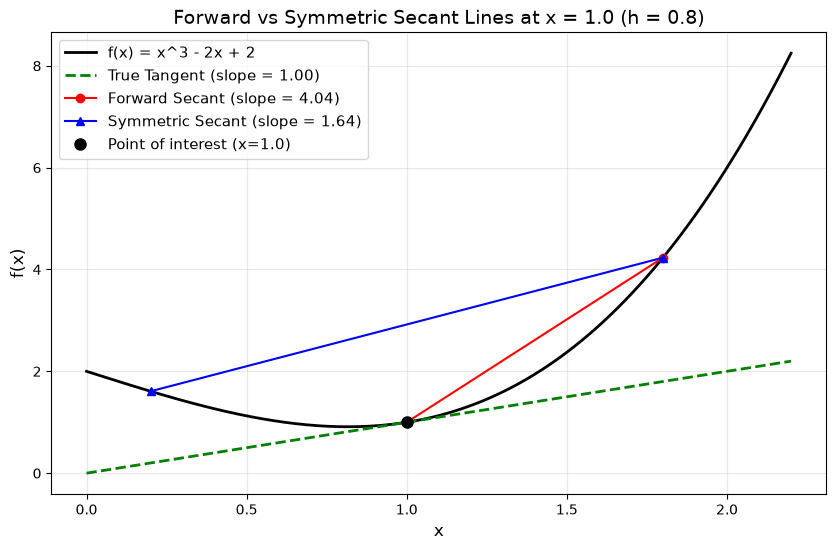

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Let's visualize f(x) = x^3 - 2x + 2 at x = 1.0 with a step h = 0.8 to clearly see the geometry
def f(x):
    return x**3 - 2*x + 2

# Exact analytical derivative: f'(x) = 3x^2 - 2
def df_exact(x):
    return 3*x**2 - 2

x0 = 1.0
h = 0.8

x_vals = np.linspace(0.0, 2.2, 200)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'k-', label="f(x) = x^3 - 2x + 2", linewidth=2)

# 1. True Tangent Line at x0
tangent_slope = df_exact(x0)
plt.plot(x_vals, f(x0) + tangent_slope * (x_vals - x0), 'g--', label=f"True Tangent (slope = {tangent_slope:.2f})", linewidth=2)

# 2. Forward Difference Secant (from x0 to x0+h)
forward_slope = (f(x0 + h) - f(x0)) / h
plt.plot([x0, x0 + h], [f(x0), f(x0 + h)], 'ro-', label=f"Forward Secant (slope = {forward_slope:.2f})")

# 3. Symmetric Difference Secant (from x0-h to x0+h)
sym_slope = (f(x0 + h) - f(x0 - h)) / (2 * h)
plt.plot([x0 - h, x0 + h], [f(x0 - h), f(x0 + h)], 'b^-', label=f"Symmetric Secant (slope = {sym_slope:.2f})")

plt.plot(x0, f(x0), 'ko', markersize=8, label=f"Point of interest (x={x0})")
plt.title(f"Forward vs Symmetric Secant Lines at x = {x0} (h = {h})", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("f(x)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

---
## 2. The Taylor Series Proof: Why is Symmetric Difference so much better?

Why does the blue symmetric line match the true tangent slope so much better than the forward red line?
Let's prove it using **Taylor Series Expansion**.

Any smooth function $f(x)$ around a point $x$ can be expanded in powers of $h$:

### Step 1: Expand $f(x + h)$
$$f(x + h) = f(x) + f'(x)h + \frac{1}{2}f''(x)h^2 + \frac{1}{6}f'''(x)h^3 + O(h^4) \quad \text{--- (Equation 1)}$$

### Step 2: Expand $f(x - h)$
Substitute $-h$ in place of $h$. Notice that odd powers get a minus sign, but even powers remain positive:
$$f(x - h) = f(x) - f'(x)h + \frac{1}{2}f''(x)h^2 - \frac{1}{6}f'''(x)h^3 + O(h^4) \quad \text{--- (Equation 2)}$$

---
### Analyzing Forward Difference Error:
Take Equation 1, subtract $f(x)$ and divide by $h$:
$$\frac{f(x + h) - f(x)}{h} = f'(x) + \underbrace{\frac{1}{2}f''(x)h}_{\text{Leading Error Term: } O(h)} + O(h^2)$$

- The error is dominated by $\frac{1}{2}f''(x)h$.
- This means the error is proportional to $h^1$ (**First-order accurate**, denoted $O(h)$).
- If you decrease $h$ by $10\times$, the error only drops by $10\times$.

---
### Analyzing Symmetric Difference Error:
Subtract Equation 2 from Equation 1:
$$f(x + h) - f(x - h) = \Big(f(x) - f(x)\Big) + \Big(f'(x)h - (-f'(x)h)\Big) + \Big(\frac{1}{2}f''(x)h^2 - \frac{1}{2}f''(x)h^2\Big) + \Big(\frac{1}{6}f'''(x)h^3 - (-\frac{1}{6}f'''(x)h^3)\Big) + \dots$$

Look at the $h^2$ curvature terms: $\frac{1}{2}f''(x)h^2 - \frac{1}{2}f''(x)h^2 = 0$! **They cancel out completely!**

We are left with:
$$f(x + h) - f(x - h) = 2f'(x)h + \frac{1}{3}f'''(x)h^3 + O(h^5)$$

Now divide both sides by $2h$:
$$\frac{f(x + h) - f(x - h)}{2h} = f'(x) + \underbrace{\frac{1}{6}f'''(x)h^2}_{\text{Leading Error Term: } O(h^2)} + O(h^4)$$

- The leading error term is now proportional to $h^2$ (**Second-order accurate**, denoted $O(h^2)$)!
- If you decrease $h$ by $10\times$, the error drops by **$100\times$** ($10^2$)!
- If $h = 0.001 = 10^{-3}$, $h^2 = 10^{-6}$ (millionths instead of thousandths)!

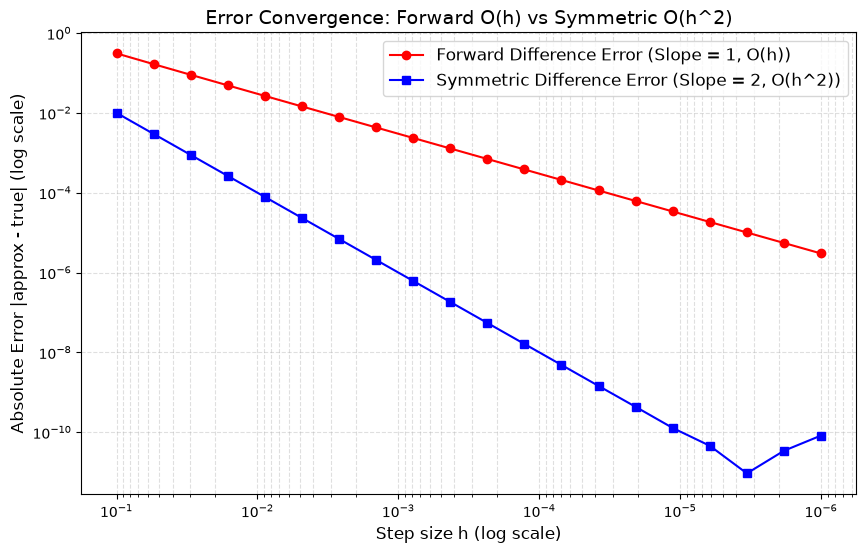

In [4]:
# Let's empirically measure the error as h gets smaller (log-log plot)
h_values = np.logspace(-1, -6, 20) # h from 0.1 down to 10^-6

forward_errors = []
sym_errors = []

x0 = 1.0
true_derivative = df_exact(x0)

for h_step in h_values:
    # Forward diff
    f_diff = (f(x0 + h_step) - f(x0)) / h_step
    forward_errors.append(abs(f_diff - true_derivative))
    
    # Symmetric diff
    s_diff = (f(x0 + h_step) - f(x0 - h_step)) / (2 * h_step)
    sym_errors.append(abs(s_diff - true_derivative))

plt.figure(figsize=(10, 6))
plt.loglog(h_values, forward_errors, 'r-o', label="Forward Difference Error (Slope = 1, O(h))")
plt.loglog(h_values, sym_errors, 'b-s', label="Symmetric Difference Error (Slope = 2, O(h^2))")
plt.gca().invert_xaxis() # larger h on left, smaller h on right
plt.xlabel("Step size h (log scale)", fontsize=12)
plt.ylabel("Absolute Error |approx - true| (log scale)", fontsize=12)
plt.title("Error Convergence: Forward O(h) vs Symmetric O(h^2)", fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=12)
plt.show()

---
## 3. Extending to Multivariable Functions $f(a, b, c)$

When a function has multiple inputs, e.g. $f(a, b, c)$:

To compute the partial derivative with respect to $a$ ($\frac{\partial f}{\partial a}$):
- We keep $b$ and $c$ constant.
- We evaluate $f(a + h, b, c)$ and $f(a - h, b, c)$.
- The symmetric partial derivative is:
$$\frac{\partial f}{\partial a} \approx \frac{f(a + h, b, c) - f(a - h, b, c)}{2h}$$

Similarly for $b$ and $c$:
$$\frac{\partial f}{\partial b} \approx \frac{f(a, b + h, c) - f(a, b - h, c)}{2h}$$
$$\frac{\partial f}{\partial c} \approx \frac{f(a, b, c + h) - f(a, b, c - h)}{2h}$$

---
## 4. Check Your Understanding: Exercises

Complete the functions below and run the test cells to verify your solutions with `OK` / `WRONG!` indicators.

### Exercise 1: Scalar Symmetric Derivative vs Analytical
Given $g(x) = e^{2x} + \cos(x)$:
1. Implement `g(x)`.
2. Implement `dg_analytical(x)` by taking the derivative analytically (chain rule on $e^{2x}$ and derivative of $\cos(x)$).
3. Implement `symmetric_diff(fn, x, h)`.
4. Implement `forward_diff(fn, x, h)`.

In [7]:
import math

def g(x):
    # TODO
    return math.exp(2*x) + math.cos(x)

def dg_analytical(x):
    # TODO
    return (math.exp(2*x) * 2) - math.sin(x)

def forward_diff(fn, x, h):
    # TODO 
    return (fn(x+h) - fn(x))/h
    
def symmetric_diff(fn, x, h):
    # TODO
    return (fn(x+h) - fn(x-h))/(2*h)

In [8]:
# === Test Suite for Exercise 1 ===
x_test = 0.5
h_test = 1e-3

expected_g = 3.595864390349418
expected_dg = 4.957138118313887

# 1. Test g(x)
yours_g = g(x_test)
ok_g = 'OK' if yours_g is not None and abs(yours_g - expected_g) < 1e-5 else 'WRONG!'
print(f"{ok_g} for g(0.5): expected {expected_g}, yours returned {yours_g}")

# 2. Test dg_analytical(x)
yours_dg = dg_analytical(x_test)
ok_dg = 'OK' if yours_dg is not None and abs(yours_dg - expected_dg) < 1e-5 else 'WRONG!'
print(f"{ok_dg} for dg_analytical(0.5): expected {expected_dg}, yours returned {yours_dg}")

# 3. Test symmetric_diff with h=1e-3 (should match analytical derivative to < 1e-5)
yours_sym = symmetric_diff(g, x_test, h_test)
ok_sym = 'OK' if yours_sym is not None and abs(yours_sym - expected_dg) < 1e-5 else 'WRONG!'
print(f"{ok_sym} for symmetric_diff (h=1e-3): expected ~{expected_dg}, yours returned {yours_sym}")

# 4. Check that symmetric_diff is strictly more accurate than forward_diff
yours_fwd = forward_diff(g, x_test, h_test)
if yours_sym is not None and yours_fwd is not None and yours_dg is not None:
    err_sym = abs(yours_sym - yours_dg)
    err_fwd = abs(yours_fwd - yours_dg)
    ok_better = 'OK' if err_sym < err_fwd / 100 else 'WRONG!'
    print(f"{ok_better}: symmetric error ({err_sym:.2e}) is >100x smaller than forward error ({err_fwd:.2e})")

OK for g(0.5): expected 3.595864390349418, yours returned 3.595864390349418
OK for dg_analytical(0.5): expected 4.957138118313887, yours returned 4.957138118313887
OK for symmetric_diff (h=1e-3): expected ~4.957138118313887, yours returned 4.957141822594657
OK: symmetric error (3.70e-06) is >100x smaller than forward error (5.00e-03)


### Exercise 2: Multivariable Symmetric Gradient
Given $q(x, y) = x^2 y + \sin(x \cdot y)$ at $(x = 1.5, y = 2.0)$:
1. Implement `q(x, y)`.
2. Implement `grad_q_analytical(x, y)` which returns `[dq/dx, dq/dy]`.
3. Implement `grad_q_symmetric(x, y, h)` which computes the gradient numerically using the symmetric difference formula for each dimension with $h = 10^{-4}$.

In [12]:
import math

def q(x, y):
    # TODO
    return (x**2)*y + math.sin(x * y) 

def grad_q_analytical(x, y):
    # TODO 
    # [dq/dx, dq/dy]
    dqdx = 2*x*y + math.cos(x*y) * y
    dqdy = (x**2) + math.cos(x*y) * x
    return [dqdx, dqdy]
    
def grad_q_symmetric(x, y, h=1e-4):
    # TODO
    # [dq_dx_num, dq_dy_num]
    dqdx = (q(x+h, y) - q(x-h, y)) / (2*h)
    dqdy = (q(x, y+h) - q(x, y-h)) / (2*h)
    return [dqdx, dqdy]

In [13]:
# === Test Suite for Exercise 2 ===
x_test, y_test = 1.5, 2.0
h_test = 1e-4

expected_grad = [4.020011786523992, 0.7650088398929943] # [dq/dx, dq/dy]

yours_analytical = grad_q_analytical(x_test, y_test)
yours_symmetric = grad_q_symmetric(x_test, y_test, h_test)

for dim, name in enumerate(["dq/dx", "dq/dy"]):
    # Test analytical
    ok_a = 'OK' if yours_analytical is not None and abs(yours_analytical[dim] - expected_grad[dim]) < 1e-5 else 'WRONG!'
    print(f"{ok_a} for analytical {name}: expected {expected_grad[dim]}, yours returned {yours_analytical[dim] if yours_analytical else None}")
    
    # Test numerical symmetric
    ok_s = 'OK' if yours_symmetric is not None and abs(yours_symmetric[dim] - expected_grad[dim]) < 1e-5 else 'WRONG!'
    print(f"{ok_s} for symmetric {name}: expected {expected_grad[dim]}, yours returned {yours_symmetric[dim] if yours_symmetric else None}")

OK for analytical dq/dx: expected 4.020011786523992, yours returned 4.02001500679911
OK for symmetric dq/dx: expected 4.020011786523992, yours returned 4.020015020000933
OK for analytical dq/dy: expected 0.7650088398929943, yours returned 0.7650112550993318
OK for symmetric dq/dy: expected 0.7650088398929943, yours returned 0.7650112606683024
